In [1]:
from web3 import Web3

# Ganache
w3 = Web3(Web3.HTTPProvider('http://127.0.0.1:7545'))  # Change if using a different node

# Contract address
contract_address = '0x411436d387fe88c233114983c68fEE7BA375fAaC'

# ABI
abi = [
    {
        "inputs": [],
        "stateMutability": "nonpayable",
        "type": "constructor"
    },
    {
        "anonymous": False,
        "inputs": [
            {"indexed": False, "internalType": "string", "name": "packageId", "type": "string"},
            {"indexed": False, "internalType": "uint256", "name": "timestamp", "type": "uint256"},
            {"indexed": False, "internalType": "string", "name": "city", "type": "string"},
            {"indexed": False, "internalType": "string", "name": "barangay", "type": "string"},
            {"indexed": False, "internalType": "int256", "name": "latitude", "type": "int256"},
            {"indexed": False, "internalType": "int256", "name": "longitude", "type": "int256"},
            {"indexed": False, "internalType": "int256", "name": "temperatureCelsius", "type": "int256"},
            {"indexed": False, "internalType": "string", "name": "status", "type": "string"}
        ],
        "name": "PackageUpdated",
        "type": "event"
    },
    {
        "inputs": [
            {"internalType": "string", "name": "packageId", "type": "string"},
            {"internalType": "string", "name": "city", "type": "string"},
            {"internalType": "string", "name": "barangay", "type": "string"},
            {"internalType": "int256", "name": "latitude", "type": "int256"},
            {"internalType": "int256", "name": "longitude", "type": "int256"},
            {"internalType": "int256", "name": "temperatureCelsius", "type": "int256"},
            {"internalType": "string", "name": "status", "type": "string"}
        ],
        "name": "storeUpdate",
        "outputs": [],
        "stateMutability": "nonpayable",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "getAllPackageIds",
        "outputs": [{"internalType": "string[]", "name": "", "type": "string[]"}],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [{"internalType": "string", "name": "packageId", "type": "string"}],
        "name": "getLatestUpdate",
        "outputs": [
            {"internalType": "uint256", "name": "timestamp", "type": "uint256"},
            {"internalType": "string", "name": "city", "type": "string"},
            {"internalType": "string", "name": "barangay", "type": "string"},
            {"internalType": "int256", "name": "latitude", "type": "int256"},
            {"internalType": "int256", "name": "longitude", "type": "int256"},
            {"internalType": "int256", "name": "temperatureCelsius", "type": "int256"},
            {"internalType": "string", "name": "status", "type": "string"}
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [
            {"internalType": "string", "name": "packageId", "type": "string"},
            {"internalType": "uint256", "name": "index", "type": "uint256"}
        ],
        "name": "getUpdateByIndex",
        "outputs": [
            {"internalType": "uint256", "name": "timestamp", "type": "uint256"},
            {"internalType": "string", "name": "city", "type": "string"},
            {"internalType": "string", "name": "barangay", "type": "string"},
            {"internalType": "int256", "name": "latitude", "type": "int256"},
            {"internalType": "int256", "name": "longitude", "type": "int256"},
            {"internalType": "int256", "name": "temperatureCelsius", "type": "int256"},
            {"internalType": "string", "name": "status", "type": "string"}
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [{"internalType": "string", "name": "packageId", "type": "string"}],
        "name": "getUpdateCount",
        "outputs": [{"internalType": "uint256", "name": "", "type": "uint256"}],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "MAX_ENTRIES",
        "outputs": [{"internalType": "uint256", "name": "", "type": "uint256"}],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "owner",
        "outputs": [{"internalType": "address", "name": "", "type": "address"}],
        "stateMutability": "view",
        "type": "function"
    }
]

# Create contract instance
contract = w3.eth.contract(address=contract_address, abi=abi)

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Cities and their prominent barangays (20 each)
locations = [
    {
        "city": "Caloocan",
        "lat": 14.6561,
        "lon": 120.9830,
        "barangays": [
            "Bagong Barrio", "Grace Park East", "Grace Park West", "Maypajo", "Monumento", "Sangandaan", "Camarin", "Bagumbong", "Deparo", "Tala",
            "North Bay Boulevard North", "North Bay Boulevard South", "10th Avenue", "11th Avenue", "12th Avenue", "Kaunlaran Village", "Bagong Silang", "Pangarap Village", "Barrio San Jose", "Barrio Sta. Quiteria"
        ]
    },
    {
        "city": "San Jose del Monte, Bulacan",
        "lat": 15.1502,
        "lon": 120.9696,
        "barangays": [
            "Muzon", "Sapang Palay Proper", "Gaya-Gaya", "Sto. Cristo", "Tungkong Mangga", "Minuyan Proper", "San Manuel", "San Martin de Porres", "San Rafael I", "San Rafael II",
            "San Pedro", "San Roque", "Citrus", "Graceville", "Kaypian", "Poblacion", "Fatima I", "Fatima II", "Fatima III", "Fatima IV"
        ]
    },
    {
        "city": "Pasig",
        "lat": 14.5764,
        "lon": 121.0851,
        "barangays": [
            "Bagong Ilog", "Bambang", "Buting", "Caniogan", "Kapasigan", "Kapitolyo", "Malinao", "Manggahan", "Maybunga", "Oranbo",
            "Palatiw", "Pinagbuhatan", "Pineda", "Rosario", "Sagad", "San Antonio", "San Joaquin", "San Jose", "San Miguel", "Sta. Lucia"
        ]
    },
    {
        "city": "Pasay",
        "lat": 14.5378,
        "lon": 121.0014,
        "barangays": [
            "Baclaran", "Baltao", "Bangkal", "Maricaban", "San Isidro", "San Jose", "San Rafael", "San Roque", "Sta. Clara", "Sta. Cruz",
            "Sta. Lucia", "Sta. Rita", "Sto. Niño", "Tambo", "Tramo", "Villamor", "Malibay", "P. Villanueva", "201 Zone 20", "183 Zone 19"
        ]
    },
    {
        "city": "Manila",
        "lat": 14.5995,
        "lon": 120.9842,
        "barangays": [
            "Tondo", "Binondo", "Ermita", "Intramuros", "Malate", "Paco", "Pandacan", "Port Area", "Quiapo", "Sampaloc",
            "San Andres", "San Miguel", "San Nicolas", "Santa Ana", "Santa Cruz", "Santa Mesa", "University Belt", "Balut", "Gagalangin", "Sta. Elena"
        ]
    }
]

statuses = ['in transit', 'delivered', 'delayed']

data = []
num_records = 100

for _ in range(num_records):
    loc = random.choice(locations)
    barangay = random.choice(loc["barangays"])
    record = {
        "timestamp": datetime.now() - timedelta(minutes=np.random.randint(0, 1440)),
        "package_id": f"PKG{np.random.randint(1000, 9999)}",
        "city": loc["city"],
        "barangay": barangay,
        "latitude": loc["lat"],
        "longitude": loc["lon"],
        "temperature_celsius": round(np.random.uniform(20.0, 30.0), 1),
        "status": random.choice(statuses)
    }
    data.append(record)

df = pd.DataFrame(data)
print(df.head()) 

df.to_csv('sample_packages.csv', index=False)

                   timestamp package_id                         city  \
0 2025-07-02 13:37:18.608291    PKG4189                        Pasay   
1 2025-07-02 02:29:18.608426    PKG4865                       Manila   
2 2025-07-02 20:31:18.608453    PKG2817                        Pasay   
3 2025-07-02 04:43:18.608474    PKG1231  San Jose del Monte, Bulacan   
4 2025-07-02 09:48:18.608493    PKG7024                     Caloocan   

          barangay  latitude  longitude  temperature_celsius      status  
0            Tambo   14.5378   121.0014                 25.9     delayed  
1  University Belt   14.5995   120.9842                 21.7   delivered  
2       San Isidro   14.5378   121.0014                 23.2  in transit  
3        Gaya-Gaya   15.1502   120.9696                 26.4   delivered  
4      10th Avenue   14.6561   120.9830                 26.3     delayed  


In [6]:
account = w3.eth.accounts[0]  

row = df.iloc[0]

# Prepare the transaction
tx = contract.functions.storeUpdate(
    row['package_id'],
    row['city'],
    row['barangay'],
    int(row['latitude'] * 1e6),  # Convert to int if needed
    int(row['longitude'] * 1e6),
    int(row['temperature_celsius'] * 10),  # Convert to int if needed
    row['status']
).build_transaction({
    'from': account,
    'nonce': w3.eth.get_transaction_count(account),
    'gas': 2000000,
    'gasPrice': w3.to_wei('20', 'gwei')
})

# Send the transaction (for unlocked Ganache account)
tx_hash = w3.eth.send_transaction(tx)
print(f"Transaction sent: {tx_hash.hex()}")

Transaction sent: 65461a0db5ce986afe27e01afe3193d4bd673272d06dbff854874b11d3cd34b9


In [ ]:
# Retrieve dara
result = contract.functions.getLatestUpdate(row['package_id']).call()

# Display the result
print("Latest update for package:", row['package_id'])
print("timestamp:", result[0])
print("city:", result[1])
print("barangay:", result[2])
print("latitude:", result[3])
print("longitude:", result[4])
print("temperatureCelsius:", result[5])
print("status:", result[6])

Latest update for package: PKG4189
timestamp: 1751463624
city: Pasay
barangay: Tambo
latitude: 14537800
longitude: 121001400
temperatureCelsius: 259
status: delayed


In [14]:
num_packages = 100  # Number of unique packages to send
updates_per_package = 2  # Number of updates per package

sent_packages = df['package_id'].unique()[:num_packages]

for pkg_id in sent_packages:
    row = df[df['package_id'] == pkg_id].iloc[0]
    for i in range(updates_per_package):
        temp = int((row['temperature_celsius'] + i) * 10)
        tx = contract.functions.storeUpdate(
            pkg_id,
            row['city'],
            row['barangay'],
            int(row['latitude'] * 1e6),
            int(row['longitude'] * 1e6),
            temp,
            row['status']
        ).build_transaction({
            'from': account,
            'nonce': w3.eth.get_transaction_count(account),
            'gas': 2000000,
            'gasPrice': w3.to_wei('20', 'gwei')
        })
        tx_hash = w3.eth.send_transaction(tx)
        print(f"Sent update {i+1} for package {pkg_id}: {tx_hash.hex()}")

Sent update 1 for package PKG4189: 65047c997334cd2bb3d798a65d1008b8caf5a5f037f4c1fc433b4c05322e1a06
Sent update 2 for package PKG4189: fa5c8ab6bca9212b0af4cc5f70c269ae5f74d318d4a0e92e8910a168ac2126f7
Sent update 1 for package PKG4865: 3aa312345582fc51ac77bb3f503e321ab169644a881b12f716948e6ae552d879
Sent update 2 for package PKG4865: 64385e96a89cd046125bedfef21bfea7b42f546c142a775e4d2362f31ece4ef1
Sent update 1 for package PKG2817: 8ac0bfcb2548c03ca77dab88922e390c635c9fe025b9f7226fede4855deaefbf
Sent update 2 for package PKG2817: 92ad6b15cccaf356e11ea07c2a9ec9a6603ab4a05cfaf2a765e809b67669d649
Sent update 1 for package PKG1231: 5c82bd1ebbc2136ec312b638c1ca41e5ced3ea82ab51feb36811b8c589511d25
Sent update 2 for package PKG1231: 31abc7a111486046175b899719f8ecf6cd69e6fa9a96167c46622b8228eaed75
Sent update 1 for package PKG7024: 6952f191b8db21815d1bbaeea237d0504bdac94d4535334164176e6d9ff7fa4c
Sent update 2 for package PKG7024: 673497e36f31ec6e7e5bc0574fb88d45dab2267a17f8146a69796043a4429e19


In [15]:
import pandas as pd

# Get all package IDs from the contract
package_ids = contract.functions.getAllPackageIds().call()

all_updates = []
for package_id in package_ids:
    update_count = contract.functions.getUpdateCount(package_id).call()
    for i in range(update_count):
        result = contract.functions.getUpdateByIndex(package_id, i).call()
        all_updates.append({
            "package_id": package_id,
            "timestamp": result[0],
            "city": result[1],
            "barangay": result[2],
            "latitude": result[3] / 1e6,
            "longitude": result[4] / 1e6,
            "temperatureCelsius": result[5] / 10,
            "status": result[6]
        })

df_all = pd.DataFrame(all_updates)
df_all['datetime'] = pd.to_datetime(df_all['timestamp'], unit='s')
df_all = df_all.sort_values(['package_id', 'datetime'])

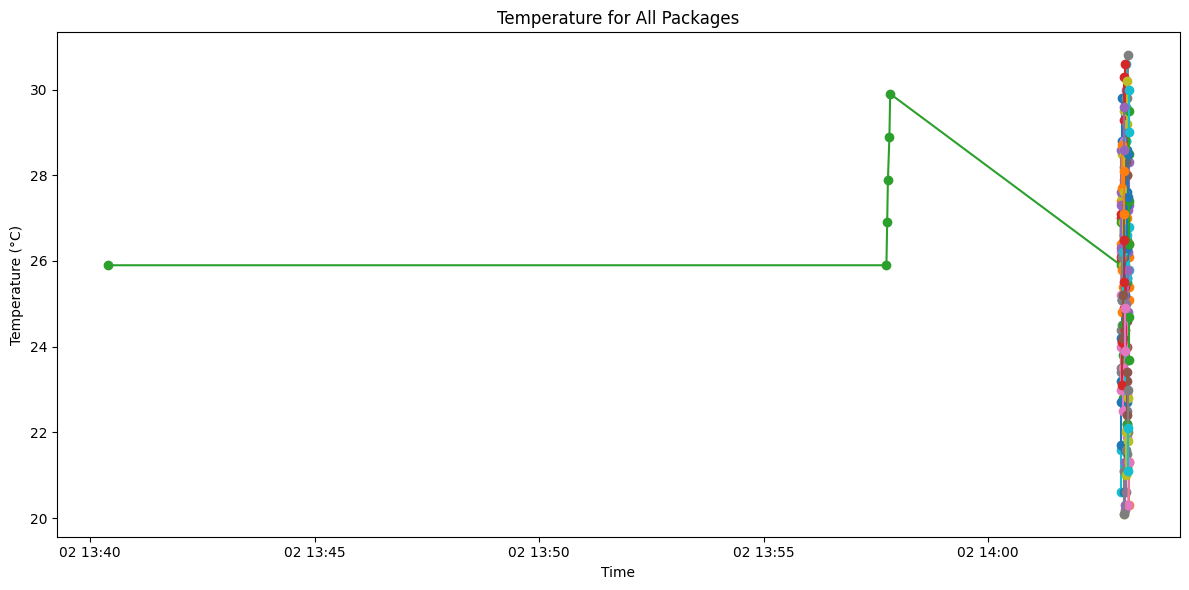

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for pkg in df_all['package_id'].unique():
    subset = df_all[df_all['package_id'] == pkg]
    plt.plot(subset['datetime'], subset['temperatureCelsius'], marker='o', label=pkg)
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature for All Packages')
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()

In [20]:
# Show the most recent city, barangay, and status for each package
latest = df_all.sort_values('datetime').groupby('package_id').tail(1)
display(latest[['package_id', 'city', 'barangay', 'status']].reset_index(drop=True))

,package_id,city,barangay,status
0,PKG4865,Manila,University Belt,delivered
1,PKG2817,Pasay,San Isidro,in transit
2,PKG1231,"San Jose del Monte, Bulacan",Gaya-Gaya,delivered
3,PKG7024,Caloocan,10th Avenue,delayed
4,PKG4189,Pasay,Tambo,delayed
...,...,...,...,...
95,PKG8895,Manila,Sta. Elena,in transit
96,PKG4031,"San Jose del Monte, Bulacan",Fatima I,delayed
97,PKG8519,Manila,San Andres,delayed
98,PKG9327,"San Jose del Monte, Bulacan",San Manuel,delayed


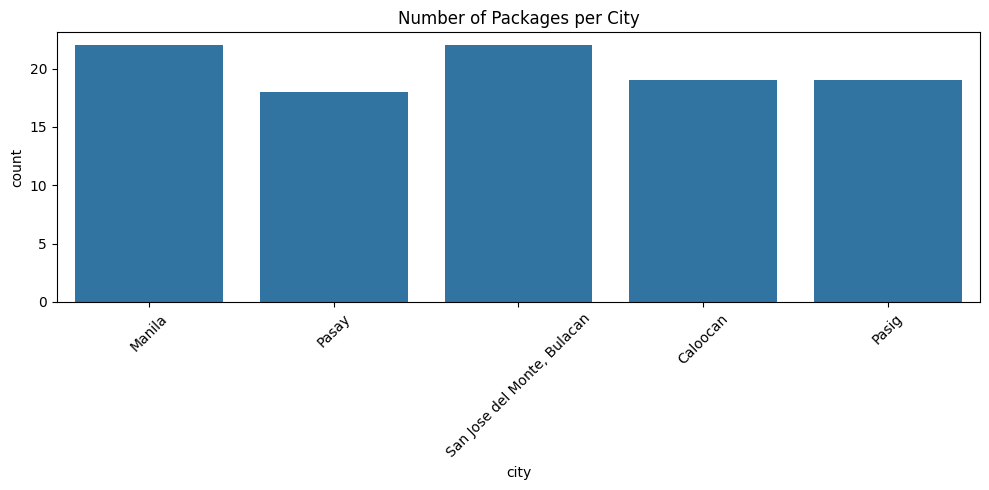

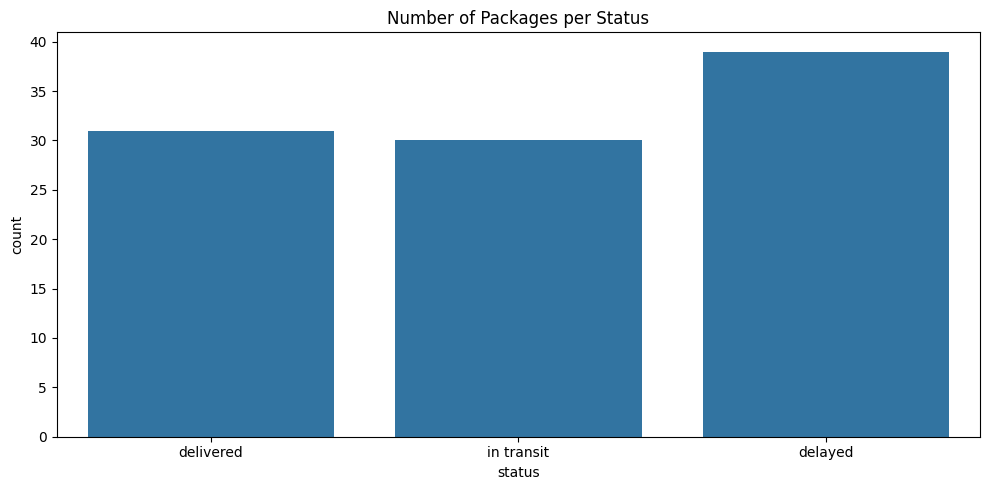

In [21]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=latest, x='city')
plt.title('Number of Packages per City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=latest, x='status')
plt.title('Number of Packages per Status')
plt.tight_layout()
plt.show()

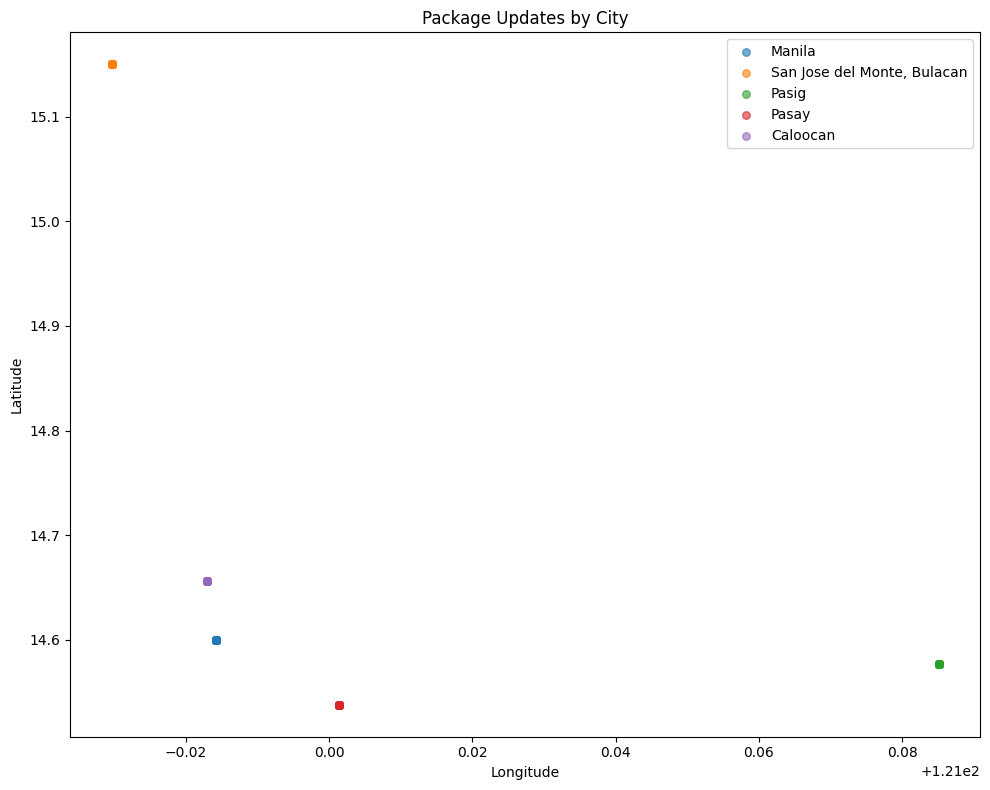

In [24]:
plt.figure(figsize=(10, 8))
for city in df_all['city'].unique():
    subset = df_all[df_all['city'] == city]
    plt.scatter(subset['longitude'], subset['latitude'], label=city, alpha=0.6, s=30)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Package Updates by City')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
!pip install folium


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import folium

# Center map on average location
center_lat = df_all['latitude'].mean()
center_lon = df_all['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

for _, row in df_all.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        popup=f"Package: {row['package_id']}<br>City: {row['city']}<br>Status: {row['status']}",
        color='blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m  # Display in Jupyter